In [1]:
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

In [2]:
import numpy as np
import sys
import os
from lime_ndt.ndt.model.Neural_Decision_Tree import NDTRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor

class NDT_not_finetunedRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, D, gammas=[100, 1], tree_id=None, sigma=0, 
                 gamma_activation=True, max_depth=5, random_state=42, epochs=10):
        self.D = D
        self.gammas = gammas
        self.tree_id = tree_id
        self.sigma = sigma
        self.gamma_activation = gamma_activation
        self.max_depth = max_depth
        self.random_state = random_state
        self.epochs = epochs
        self.ndt = None

    def fit(self, X, y, sample_weight=None):
        self.ndt = NDTRegressor(num_features=self.D, gammas=self.gammas, tree_id=self.tree_id, 
                                sigma=self.sigma, gamma_activation=self.gamma_activation)
        tree = DecisionTreeRegressor(max_depth=self.max_depth,
                                     random_state=self.random_state).fit(X, y)
        self.ndt.compute_matrices_and_biases(tree)
        self.ndt.to_keras(loss='mean_squared_error')
        self.intercept_ = np.mean(y)
        return self

    def predict(self, X):
        return self.ndt.predict(X).flatten()

    @property
    def coef_(self):
        # Multiplication des 3 matrices pour obtenir l'impact global des features
        W1 = self.ndt.W_in_nodes.values            # features -> nodes
        W2 = self.ndt.W_nodes_leaves.values        # nodes -> leaves
        W3 = self.ndt.W_leaves_out.values          # leaves -> output
        coef_matrix = W1 @ W2 @ W3
        return coef_matrix.mean(axis=1)            # importance moyenne par feature

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


...

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


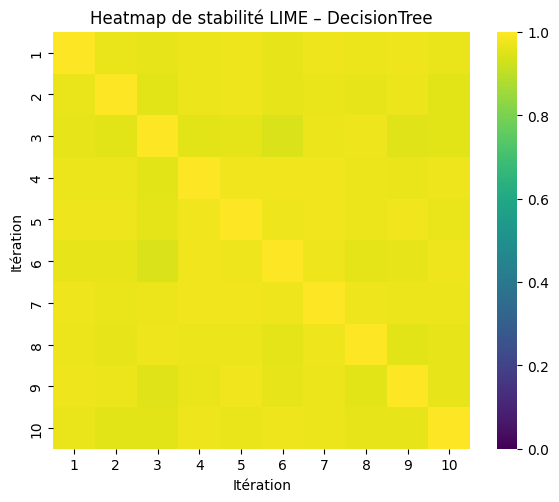

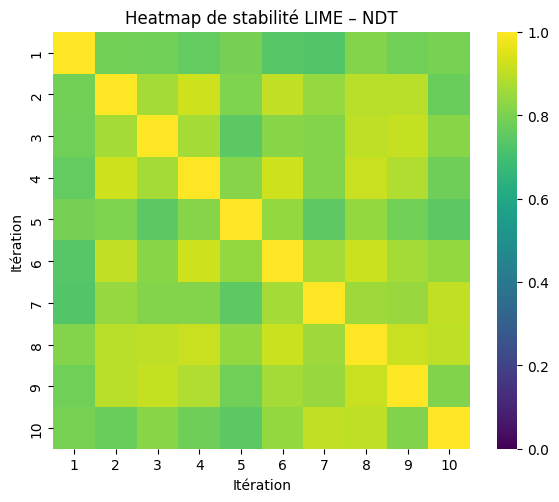


=== Stabilité moyenne (hors diagonale) ===
DecisionTree: 0.968
NDT: 0.835


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics.pairwise import cosine_similarity

# LIME classique
from lime.lime_tabular import LimeTabularExplainer as LimeClassicExplainer
# LIME-NDT
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# ========================
# 0. Wrapper DecisionTree
# ========================
class DecisionTreeWrapper(DecisionTreeRegressor):
    def fit(self, X, y, sample_weight=None, *args, **kwargs):
        super().fit(X, y, sample_weight=sample_weight, *args, **kwargs)
        self.coef_ = np.array(self.feature_importances_)
        self.intercept_ = 0
        return self

# ========================
# 1. Dataset
# ========================
data = load_digits()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ========================
# 2. Modèle global
# ========================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

def predict_fn(X):
    return rf.predict_proba(X)

# ========================
# 3. Explainers
# ========================
explainer_classic = LimeClassicExplainer(
    X_train,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=False,
    mode="classification",
)

explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=False,
    mode="classification",
)

# ========================
# 4. Matrice de stabilité
# ========================
def explanation_stability_matrix(
    explainer,
    model_regressor,
    instance_id=0,
    n_repeats=10,
    num_features=13,
):
    explanations = []

    for seed in range(n_repeats):
        np.random.seed(seed)

        exp = explainer.explain_instance(
            X_test[instance_id],
            predict_fn,
            num_features=num_features,
            model_regressor=model_regressor,
        )

        weights = dict(exp.as_list())
        vec = np.array([weights.get(f, 0) for f in feature_names])
        explanations.append(vec)

    explanations = np.array(explanations)
    return cosine_similarity(explanations)

# ========================
# 5. Calcul des matrices
# ========================
stability_matrices = {}


stability_matrices["DecisionTree"] = explanation_stability_matrix(
    explainer_ndt,
    DecisionTreeWrapper(),
    instance_id=20,
    n_repeats=10,
    num_features=len(feature_names),
)

stability_matrices["NDT"] = explanation_stability_matrix(
    explainer_ndt,
    NDTRegressorWrapper(D=X_train.shape[1], gammas=[1, 1]),
    instance_id=20,
    n_repeats=10,
    num_features=X_train.shape[1],
)

# ========================
# 6. Heatmaps
# ========================
for name, mat in stability_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        mat,
        vmin=0,
        vmax=1,
        cmap="viridis",
        square=True,
        cbar=True,
        xticklabels=range(1, 11),
        yticklabels=range(1, 11),
    )
    plt.title(f"Heatmap de stabilité LIME – {name}")
    plt.xlabel("Itération")
    plt.ylabel("Itération")
    plt.tight_layout()
    plt.show()

# ========================
# 7. Score global (optionnel)
# ========================
def mean_off_diagonal_similarity(mat):
    n = mat.shape[0]
    return (mat.sum() - np.trace(mat)) / (n * (n - 1))

print("\n=== Stabilité moyenne (hors diagonale) ===")
for name, mat in stability_matrices.items():
    score = mean_off_diagonal_similarity(mat)
    print(f"{name}: {score:.3f}")


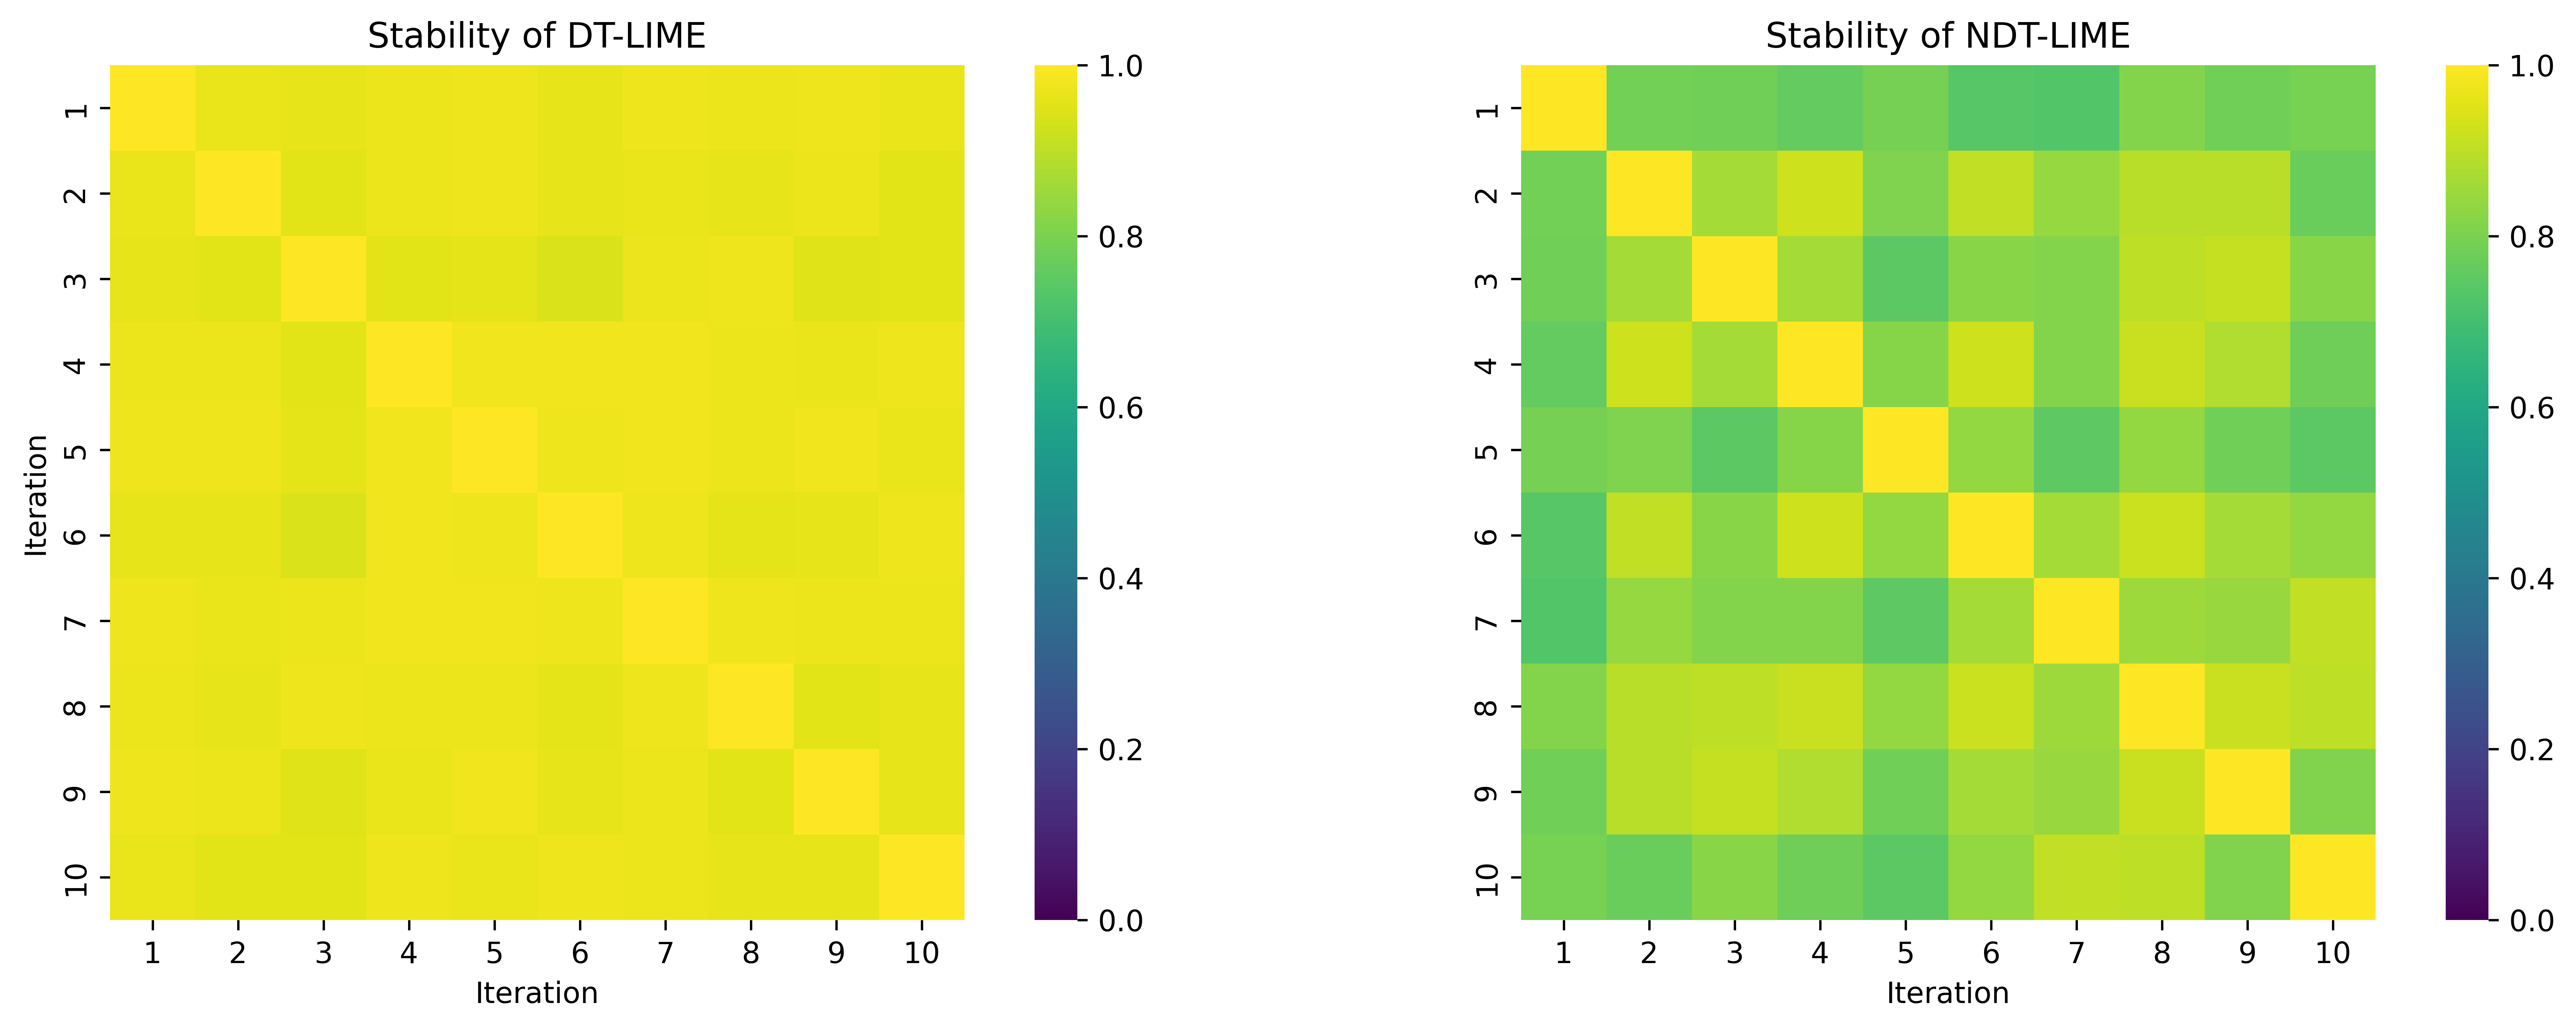

In [10]:
# ========================
# 6. Heatmaps côte à côte (haute résolution)
# ========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=600)

# --- Decision Tree ---
sns.heatmap(
    stability_matrices["DecisionTree"],
    vmin=0,
    vmax=1,
    cmap="viridis",
    square=True,
    cbar=True,
    xticklabels=range(1, 11),
    yticklabels=range(1, 11),
    ax=axes[0]
)
axes[0].set_title("Stability of DT-LIME")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Iteration")

# --- NDT ---
sns.heatmap(
    stability_matrices["NDT"],
    vmin=0,
    vmax=1,
    cmap="viridis",
    square=True,
    cbar=True,
    xticklabels=range(1, 11),
    yticklabels=range(1, 11),
    ax=axes[1]
)
axes[1].set_title("Stability of NDT-LIME")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("")

plt.tight_layout()

# 🔹 Sauvegarde ultra nette
plt.savefig("stability_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()
